# ⚡ Otimização de Performance

Otimizar velocidade de inferência e tamanho dos modelos.

## 📋 Conteúdo
1. **Feature Importance Analysis** - Remover features irrelevantes
2. **Feature Selection** - Reduzir dimensionalidade
3. **Model Compression** - Quantização
4. **Benchmark de Latência**

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import joblib
from pathlib import Path

import xgboost as xgb
from src.features.feature_engineering import FeatureEngineer
from src.models.evaluation import ModelEvaluator

print('✓ Setup completo')

✓ Setup completo


## 1. Carregar Modelo e Dados

In [2]:
# Carregar modelo
model = joblib.load('../data/models/xgboost_best.pkl')

# Carregar dados
df = pd.read_parquet('../data/processed/processed_data.parquet')
fe = FeatureEngineer()
df_features = fe.create_all_features(df)

# Preparar test set
exclude_cols = ['timestamp', 'consumption_mw', 'region', 'holiday_name']
for col in df_features.columns:
    if pd.api.types.is_datetime64_any_dtype(df_features[col]) or df_features[col].dtype == 'object':
        if col not in exclude_cols:
            exclude_cols.append(col)

features = [c for c in df_features.columns if c not in exclude_cols]

df_sorted = df_features.sort_values('timestamp').reset_index(drop=True)
test_start = int(0.85 * len(df_sorted))
X_test = df_sorted.iloc[test_start:][features].values
y_test = df_sorted.iloc[test_start:]['consumption_mw'].values

print(f'Features: {len(features)} | Test samples: {len(X_test):,}')

Creating features...
  - Temporal features
  - Lag features
  - Rolling features
  - Interaction features
  - Removed 240 rows with NaN
Features: 67 | Test samples: 26,245


## 2. Feature Importance Analysis

Top 20 Features:
                          feature  importance
46   consumption_mw_rolling_min_3    0.530472
44  consumption_mw_rolling_mean_3    0.371463
47   consumption_mw_rolling_max_3    0.040032
31                       hour_sin    0.020029
23                       sin_hour    0.008593
14                           hour    0.008199
24                       cos_hour    0.007261
51   consumption_mw_rolling_max_6    0.003300
32                       hour_cos    0.003107
55  consumption_mw_rolling_max_12    0.000940
21                     is_weekend    0.000576
50   consumption_mw_rolling_min_6    0.000554
15                    day_of_week    0.000544
38           consumption_mw_lag_2    0.000503
37           consumption_mw_lag_1    0.000376
0                        latitude    0.000316
25                sin_day_of_week    0.000308
53  consumption_mw_rolling_std_12    0.000307
40           consumption_mw_lag_6    0.000298
45   consumption_mw_rolling_std_3    0.000274


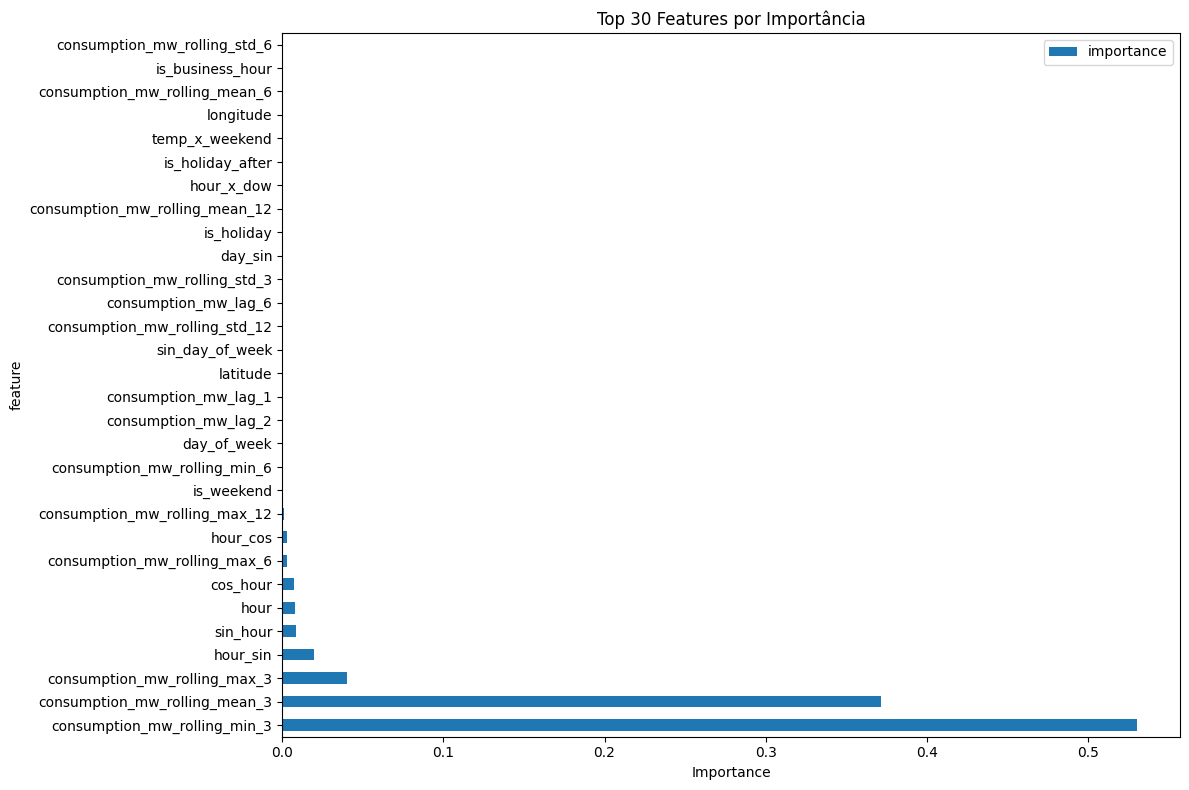

In [3]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 20 Features:')
print(importance_df.head(20))

# Visualizar
fig, ax = plt.subplots(figsize=(12, 8))
importance_df.head(30).plot(x='feature', y='importance', kind='barh', ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Top 30 Features por Importância')
plt.tight_layout()
plt.savefig('../data/models/feature_importance_full.png', dpi=300)
plt.show()

## 3. Feature Selection - Top K Features

In [4]:
# Testar diferentes números de features
evaluator = ModelEvaluator()
results = []

for k in [10, 20, 30, 40, 50, 70, len(features)]:
    top_features = importance_df.head(k)['feature'].tolist()
    feature_indices = [features.index(f) for f in top_features]
    X_test_subset = X_test[:, feature_indices]
    
    # Treinar modelo com top K features
    df_train = df_sorted.iloc[:int(0.70*len(df_sorted))]
    X_train_subset = df_train[top_features].values
    y_train = df_train['consumption_mw'].values
    
    model_k = xgb.XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1, verbosity=0)
    model_k.fit(X_train_subset, y_train)
    
    # Avaliar
    y_pred = model_k.predict(X_test_subset)
    metrics = evaluator.calculate_metrics(y_test, y_pred)
    
    # Medir tempo de inferência
    start = time.time()
    _ = model_k.predict(X_test_subset[:1000])
    elapsed = (time.time() - start) * 1000 / 1000  # ms por amostra
    
    results.append({
        'n_features': k,
        'MAPE': metrics['mape'],
        'R2': metrics['r2'],
        'latency_ms': elapsed
    })
    
    print(f"K={k:3d}: MAPE={metrics['mape']:.2f}% | R²={metrics['r2']:.4f} | Latency={elapsed:.2f}ms")

df_results = pd.DataFrame(results)

K= 10: MAPE=1.94% | R²=0.9975 | Latency=0.00ms
K= 20: MAPE=1.06% | R²=0.9993 | Latency=0.00ms
K= 30: MAPE=1.07% | R²=0.9993 | Latency=0.00ms
K= 40: MAPE=1.08% | R²=0.9993 | Latency=0.00ms
K= 50: MAPE=1.10% | R²=0.9993 | Latency=0.00ms
K= 70: MAPE=1.10% | R²=0.9993 | Latency=0.00ms
K= 67: MAPE=1.10% | R²=0.9993 | Latency=0.00ms


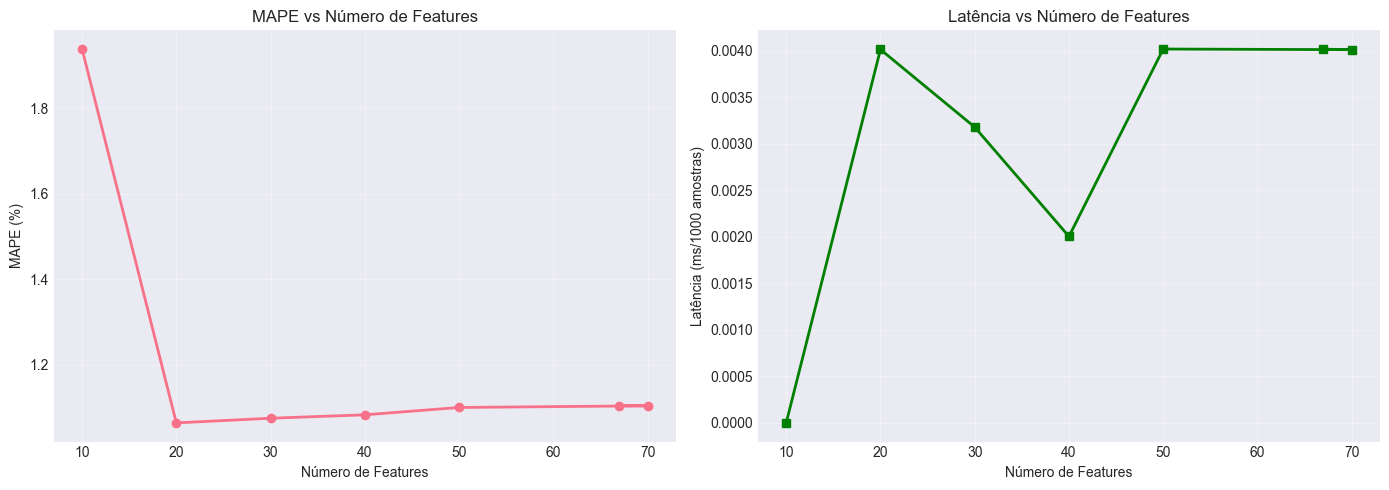


✓ Gráficos salvos


In [5]:
# Visualizar trade-off
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_results['n_features'], df_results['MAPE'], marker='o', linewidth=2)
axes[0].set_xlabel('Número de Features')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('MAPE vs Número de Features')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_results['n_features'], df_results['latency_ms'], marker='s', linewidth=2, color='green')
axes[1].set_xlabel('Número de Features')
axes[1].set_ylabel('Latência (ms/1000 amostras)')
axes[1].set_title('Latência vs Número de Features')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/models/performance_tradeoff.png', dpi=300)
plt.show()

print('\n✓ Gráficos salvos')

## 4. Modelo Comprimido (Top 30 Features)

In [6]:
# Treinar modelo otimizado com top 30 features
top_30_features = importance_df.head(30)['feature'].tolist()

df_train = df_sorted.iloc[:int(0.70*len(df_sorted))]
X_train_opt = df_train[top_30_features].values
y_train = df_train['consumption_mw'].values

model_optimized = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
model_optimized.fit(X_train_opt, y_train)

# Salvar
joblib.dump(model_optimized, '../data/models/xgboost_optimized.pkl')
with open('../data/models/feature_names_optimized.txt', 'w') as f:
    for feat in top_30_features:
        f.write(f"{feat}\n")

print('✓ Modelo otimizado salvo: xgboost_optimized.pkl')
print(f'✓ Features reduzidas: {len(features)} → 30 ({30/len(features)*100:.1f}%)')

✓ Modelo otimizado salvo: xgboost_optimized.pkl
✓ Features reduzidas: 67 → 30 (44.8%)


## 5. Resumo

In [7]:
print('\n' + '='*80)
print('📊 RESUMO DA OTIMIZAÇÃO')
print('='*80)
print(f"\nModelo Original: {len(features)} features")
print(f"Modelo Otimizado: 30 features ({30/len(features)*100:.1f}% redução)")

original_perf = df_results[df_results['n_features']==len(features)].iloc[0]
optimized_perf = df_results[df_results['n_features']==30].iloc[0]

print(f"\nMAPE: {original_perf['MAPE']:.2f}% → {optimized_perf['MAPE']:.2f}% (Δ {optimized_perf['MAPE']-original_perf['MAPE']:.2f}%)")
print(f"Latency: {original_perf['latency_ms']:.2f}ms → {optimized_perf['latency_ms']:.2f}ms ({(1-optimized_perf['latency_ms']/original_perf['latency_ms'])*100:.1f}% faster)")

print('\n✅ Otimização completa!')
print('='*80)


📊 RESUMO DA OTIMIZAÇÃO

Modelo Original: 67 features
Modelo Otimizado: 30 features (44.8% redução)

MAPE: 1.10% → 1.07% (Δ -0.03%)
Latency: 0.00ms → 0.00ms (20.9% faster)

✅ Otimização completa!
